In [4]:
import pyMesa as pym
import gfort2py 
import os
import sys
sys.path.append('../RunData')
sys.path.append('../')

import numpy as np
from subprocess import run
import subprocess
import csv
import pandas as pd
import matplotlib.pyplot as plt

print('Python version:     {}'.format(sys.version))
print('pyMesa Directory:   {}'.format(os.path.dirname(pym.__file__)))
print('gFort2py Directory: {}'.format(os.path.dirname(gfort2py.__file__)))
print('MESA_DIR:           {}'.format(pym.MESA_DIR))
print('MESASDK_ROOT:       {}'.format(pym.MESASDK_ROOT))

Python version:     3.11.6 | packaged by conda-forge | (main, Oct  3 2023, 10:40:35) [GCC 12.3.0]
pyMesa Directory:   /home/david101/.local/lib/python3.11/site-packages/pyMesa
gFort2py Directory: /home/david101/.conda/envs/Py310/lib/python3.11/site-packages/gfort2py
MESA_DIR:           /opt/mesa-r23.05.1
MESASDK_ROOT:       /opt/mesasdk-23.7.3


In [5]:
import InlistHelper as ih
import EnergyHelper as eh
import plothelpers
import EnergyHelper as eh
import MESAGen as mg
import CEphysics

G    = 6.6743e-8    
c    = 2.99792458e10    # [cm]
Msun = 1.9891e33        # [g]
Rsun = 6.957e10         # [cm]
pc   = 3.08567758128e18 # [cm]
kpc  = 1.e3*pc          # [cm]
Mpc  = 1.e6*pc          # [cm] 
au   = 1.49598073e13    # [cm]
yr   = 31556952.        # [secs]

In [6]:
# For given parametesrs, calculates energy to be deposited...
def testCaseA(modfileTest):
    Ra = np.exp(24) * 2    # Accretion Radi
    Einput = 1e40          # Energy to deposit
    nsPos  = np.exp(25)    # Accretor position
    ahi    = nsPos + Ra    # Uppper heating 
    alo    = nsPos - Ra    # Lower heating
    zones  = eh.getAccretionZones(modfileTest, ahi, alo)
    xaList, isoList = getIsotopes(modfileTest, zones)
    ez1, rt1 = eh.getEnergyDistribution(modfileTest, zones, Einput, 'Triangle')
    ez2, rt2 = eh.getEnergyDistribution(modfileTest, zones, Einput, 'Parabolic')
    ez3, rt3 = eh.getEnergyDistribution(modfileTest, zones, Einput, 'Cosine')
    ez4, rt4 = eh.getEnergyDistribution(modfileTest, zones, Einput, 'Quartic')
    ez5, rt5 = eh.getEnergyDistribution(modfileTest, zones, Einput, 'Triweight')
    ez6, rt6 = eh.getEnergyDistribution(modfileTest, zones, Einput, 'Gauss')
    ez7, rt7 = eh.getEnergyDistribution(modfileTest, zones, Einput, 'Uniform')
    ez8, rt8 = eh.getEnergyDistribution(modfileTest, zones, Einput, 'Os')
    fig, ax = plt.subplots(facecolor = 'w')
    ax.plot(zones, ez1, label = 'Triangular')
    ax.plot(zones, ez2, label = 'Parabolic')
    ax.plot(zones, ez3, label = 'Cosine') 
    ax.plot(zones, ez4, label = 'Quatric')
    ax.plot(zones, ez5, label = 'Triweight')
    ax.plot(zones, ez6, label = 'Gaussian')
    ax.plot(zones, ez7, label = 'Uniform')
    ax.plot(zones, ez8, label = 'Osciallting')
    ax.grid(True)
    ax.legend(loc='best')

In [7]:
# **** Test Case.... NS Position accretion radius ****
#context     = pyMesa_context()

modfileTest = '../StarModels/Fragos/12MsunRG550R.mod'

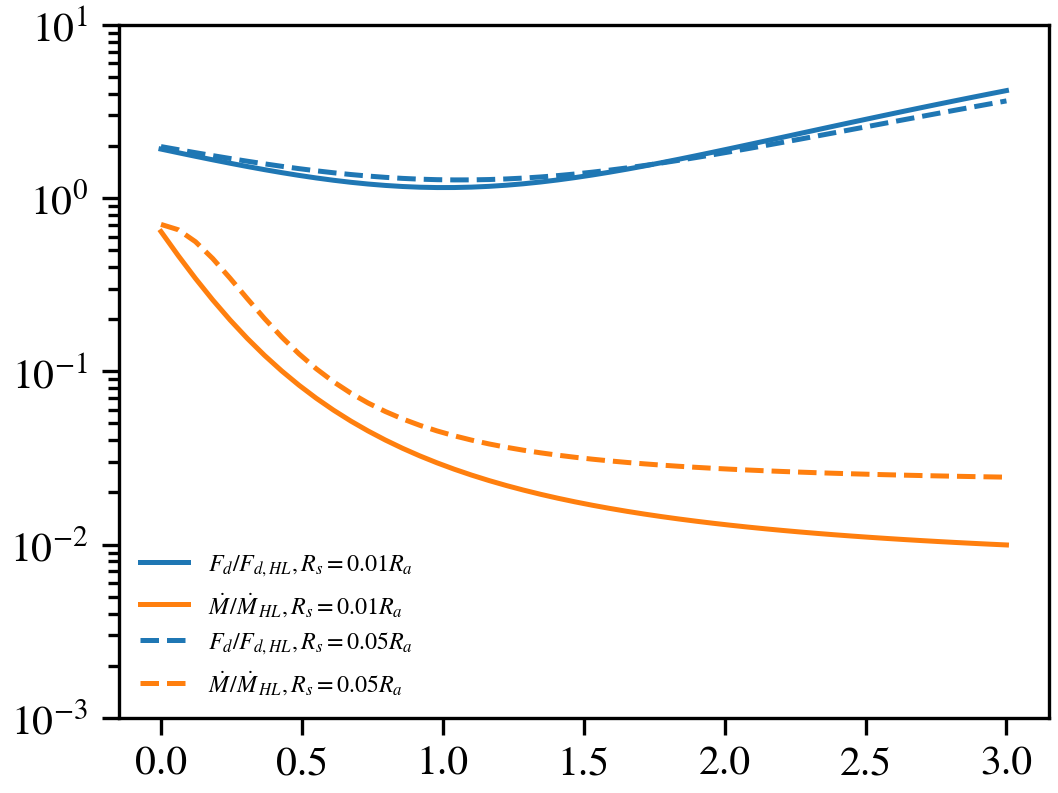

In [8]:
def testFit(ep, rs):
    if (rs == 0):
        c1,c2,c3    = 1.9179196, -1.5281498, 0.75992092
        a1,a2,a3,a4 = -2.14034214, 1.94694764, 1.19007536, 1.05762477
    else:
        c1,c2,c3 = 1.98255197, -1.3369113, 0.62963326
        a1,a2,a3,a4 = -1.65171739, 1.49979486, 0.10226072, 3.93190671
        
    Fd = c1 + (c2*ep) + (c3*ep**2)
    dM = a1 + a2/(1+(a3*ep) + (a4*ep**2) )
    dM = 10**dM
    return [Fd, dM]
ep = np.linspace(0,3, 50)
Fdsol1, dMsol1 = testFit(ep,0)
Fdsol2, dMsol2 = testFit(ep,1)

fig, ax = plt.subplots(facecolor = 'w')
ax.set(yscale = 'log', ylim = (10e-4, 10e0))

ax.plot(ep,Fdsol1, color ='tab:blue', label = '$F_{d} / F_{d,HL}, R_{s} = 0.01 R_{a}$')
ax.plot(ep,dMsol1, color ='tab:orange', label = '$\dot M / \dot M_{HL}, R_{s} = 0.01 R_{a}$')

ax.plot(ep,Fdsol2,'--', color ='tab:blue', label = '$F_{d} / F_{d,HL}, R_{s} = 0.05 R_{a}$')
ax.plot(ep,dMsol2,'--', color ='tab:orange', label = '$\dot M / \dot M_{HL}, R_{s} = 0.05 R_{a}$')

ax.legend(loc = 'best', fontsize='xx-large')